Imports and Setup

In [1]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir("C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project")

print("libraries loaded!")

libraries loaded!


Load Data

In [2]:
# connect to database
conn = sqlite3.connect("data/db/bluestock_mf.db")

# load tables
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
nav_history = pd.read_sql("SELECT * FROM fact_nav", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)

# load portfolio holdings
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

# fix dates
nav_history['date'] = pd.to_datetime(nav_history['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# calculate daily returns for all funds
nav_history = nav_history.sort_values(['amfi_code', 'date'])
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()
returns_clean = nav_history.dropna(subset=['daily_return']).copy()

print("data loaded!")
print(f"funds: {len(fund_master)}")
print(f"nav records: {len(nav_history)}")
print(f"transactions: {len(transactions)}")

data loaded!
funds: 40
nav records: 46000
transactions: 32778


VaR and CVaR 

In [3]:
# STEP 1: HISTORICAL VAR AND CVAR FOR ALL 40 FUNDS
# VaR 95% = 5th percentile of daily returns
# CVaR = average of returns below VaR threshold

print("calculating VaR and CVaR for all funds...")
print("-" * 50)

var_results = []

for code in fund_master['amfi_code'].unique():
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    
    # get daily returns for this fund
    fund_returns = returns_clean[returns_clean['amfi_code'] == code]['daily_return']
    
    if len(fund_returns) > 30:
        # calculate VaR at 95% confidence level
        # this means 5% of days had returns worse than this
        var_95 = np.percentile(fund_returns, 5)
        
        # calculate CVaR (average of worst 5% days)
        cvar_95 = fund_returns[fund_returns <= var_95].mean()
        
        var_results.append({
            'amfi_code': code,
            'scheme_name': fund_name,
            'var_95_pct': round(var_95 * 100, 3),
            'cvar_95_pct': round(cvar_95 * 100, 3),
            'total_days': len(fund_returns)
        })

# create dataframe
var_df = pd.DataFrame(var_results)
var_df = var_df.sort_values('var_95_pct')

print("\ntop 10 riskiest funds (highest VaR):")
print(var_df[['scheme_name', 'var_95_pct', 'cvar_95_pct']].head(10).to_string(index=False))

print("\ntop 10 safest funds (lowest VaR):")
print(var_df[['scheme_name', 'var_95_pct', 'cvar_95_pct']].tail(10).to_string(index=False))

# save to csv
var_df.to_csv('data/processed/var_cvar_report.csv', index=False)
print("\nsaved to data/processed/var_cvar_report.csv")

calculating VaR and CVaR for all funds...
--------------------------------------------------

top 10 riskiest funds (highest VaR):
                                       scheme_name  var_95_pct  cvar_95_pct
         SBI Small Cap Fund - Direct Plan - Growth      -2.686       -3.238
            Axis Small Cap Fund - Regular - Growth      -2.619       -3.167
            ABSL Small Cap Fund - Regular - Growth      -2.602       -3.246
    Nippon India Small Cap Fund - Regular - Growth      -2.544       -3.230
        SBI Small Cap Fund - Regular Plan - Growth      -2.451       -3.060
             DSP Small Cap Fund - Regular - Growth      -2.348       -3.104
               UTI Mid Cap Fund - Regular - Growth      -1.922       -2.325
HDFC Mid-Cap Opportunities Fund - Regular - Growth      -1.903       -2.346
          ICICI Pru Midcap Fund - Regular - Growth      -1.889       -2.434
               Axis Midcap Fund - Regular - Growth      -1.848       -2.426

top 10 safest funds (lowest VaR)

*** Rolling Sharpe Ratio ***

calculating rolling sharpe ratio...


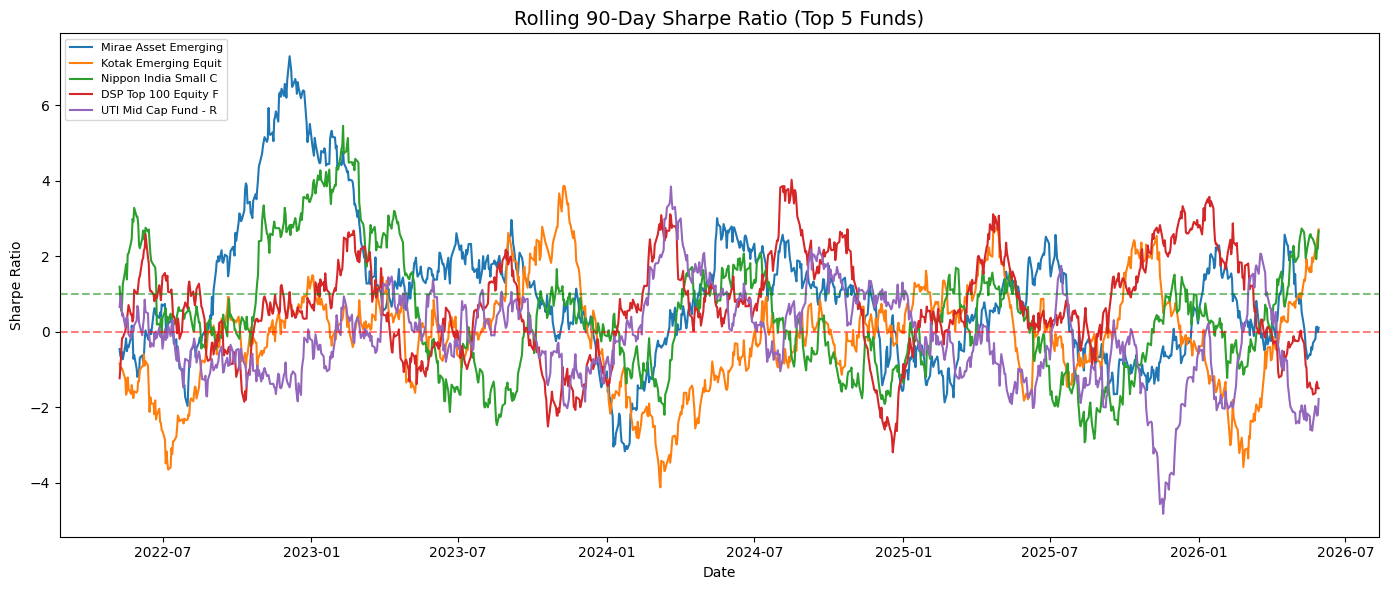

rolling sharpe chart saved!


In [4]:
# STEP 2: ROLLING 90 DAY SHARPE RATIO FOR 5 KEY FUNDS

print("calculating rolling sharpe ratio...")

# daily risk free rate
rf_daily = 0.065 / 252

# get top 5 funds by AUM
top5_codes = performance.nlargest(5, 'aum_crore')['amfi_code'].tolist()

plt.figure(figsize=(14, 6))

for code in top5_codes:
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0][:20]
    
    # get returns
    fund_data = returns_clean[returns_clean['amfi_code'] == code].sort_values('date')
    fund_returns = fund_data.set_index('date')['daily_return']
    
    # calculate rolling 90 day sharpe
    rolling_mean = fund_returns.rolling(90).mean()
    rolling_std = fund_returns.rolling(90).std()
    rolling_sharpe = (rolling_mean - rf_daily) / rolling_std * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=fund_name, linewidth=1.5)

plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(loc='upper left', fontsize=8)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='zero line')
plt.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='good sharpe')
plt.tight_layout()

plt.savefig('reports/rolling_sharpe_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("rolling sharpe chart saved!")

*** Investor Cohort Analysis ***

In [5]:
# STEP 3: INVESTOR COHORT ANALYSIS
# group investors by their first transaction year

print("running cohort analysis...")
print("-" * 50)

# find first transaction year for each investor
first_transaction = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_transaction['cohort_year'] = first_transaction['transaction_date'].dt.year
first_transaction.columns = ['investor_id', 'first_date', 'cohort_year']

# merge back with transactions
trans_cohort = transactions.merge(first_transaction[['investor_id', 'cohort_year']], on='investor_id')

# analyze each cohort
cohort_results = []

for year in sorted(trans_cohort['cohort_year'].unique()):
    cohort = trans_cohort[trans_cohort['cohort_year'] == year]
    
    # get SIP transactions only
    sip_cohort = cohort[cohort['transaction_type'] == 'SIP']
    
    # find top fund preference
    top_fund_code = cohort['amfi_code'].mode()[0]
    top_fund_name = fund_master[fund_master['amfi_code'] == top_fund_code]['scheme_name'].values
    top_fund = top_fund_name[0][:30] if len(top_fund_name) > 0 else 'Unknown'
    
    cohort_results.append({
        'cohort_year': year,
        'num_investors': cohort['investor_id'].nunique(),
        'total_invested': cohort['amount_inr'].sum(),
        'avg_sip_amount': round(sip_cohort['amount_inr'].mean(), 0) if len(sip_cohort) > 0 else 0,
        'top_fund': top_fund
    })

cohort_df = pd.DataFrame(cohort_results)
print("\ncohort analysis results:")
print(cohort_df.to_string(index=False))

running cohort analysis...
--------------------------------------------------

cohort analysis results:
 cohort_year  num_investors  total_invested  avg_sip_amount                       top_fund
        2024           4803      3491125187         10997.0 Mirae Asset Emerging Bluechip 
        2025            197        30455243         13505.0 SBI Small Cap Fund - Direct Pl


*** SIP Continuity Analysis ***

In [6]:
# STEP 4: SIP CONTINUITY ANALYSIS
# find investors with irregular SIP payments

print("running SIP continuity analysis...")
print("-" * 50)

# get SIP transactions only
sip_trans = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_trans = sip_trans.sort_values(['investor_id', 'transaction_date'])

# find investors with 6 or more SIP transactions
sip_counts = sip_trans.groupby('investor_id').size()
regular_investors = sip_counts[sip_counts >= 6].index.tolist()

print(f"investors with 6+ SIP transactions: {len(regular_investors)}")

continuity_results = []

for investor in regular_investors[:500]:  # check first 500 for speed
    investor_sips = sip_trans[sip_trans['investor_id'] == investor]['transaction_date'].sort_values()
    
    # calculate gap between consecutive SIPs
    gaps = investor_sips.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    
    # flag as at-risk if average gap > 35 days
    at_risk = avg_gap > 35
    
    continuity_results.append({
        'investor_id': investor,
        'num_sips': len(investor_sips),
        'avg_gap_days': round(avg_gap, 1),
        'at_risk': at_risk
    })

continuity_df = pd.DataFrame(continuity_results)

total = len(continuity_df)
at_risk_count = continuity_df['at_risk'].sum()
continuity_rate = round((1 - at_risk_count/total) * 100, 1)

print(f"\ntotal investors analyzed: {total}")
print(f"at-risk investors (gap > 35 days): {at_risk_count}")
print(f"SIP continuity rate: {continuity_rate}%")
print(f"\nat-risk investors sample:")
print(continuity_df[continuity_df['at_risk'] == True].head(10).to_string(index=False))

running SIP continuity analysis...
--------------------------------------------------
investors with 6+ SIP transactions: 1362

total investors analyzed: 500
at-risk investors (gap > 35 days): 488
SIP continuity rate: 2.4%

at-risk investors sample:
investor_id  num_sips  avg_gap_days  at_risk
  INV000004         6          85.4     True
  INV000008         6          70.4     True
  INV000010         6          64.8     True
  INV000011         7          40.2     True
  INV000012         8          57.0     True
  INV000013         7          55.3     True
  INV000014         7          75.3     True
  INV000023         8          58.6     True
  INV000028         6          93.6     True
  INV000029         7          60.7     True


Fund Recommender

In [7]:
# STEP 5: SIMPLE FUND RECOMMENDER
# input: risk appetite
# output: top 3 funds matching risk profile

print("building fund recommender...")
print("-" * 50)

def recommend_funds(risk_appetite):
    # map risk appetite to risk grade
    risk_map = {
        'Low': ['A', 'B'],
        'Moderate': ['B', 'C'],
        'High': ['C', 'D', 'E']
    }
    
    # get matching risk grades
    matching_grades = risk_map.get(risk_appetite, ['C'])
    
    # filter performance data
    filtered = performance[performance['risk_grade'].isin(matching_grades)].copy()
    
    # merge with fund names
    filtered = filtered.merge(
        fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']],
        on='amfi_code',
        how='left'
    )
    
    # sort by sharpe ratio
    filtered = filtered.sort_values('sharpe_ratio', ascending=False)
    
    # get top 3
    top3 = filtered.head(3)
    
    print(f"\nrecommended funds for {risk_appetite} risk appetite:")
    print("-" * 60)
    for i, row in top3.iterrows():
        print(f"Rank {top3.index.get_loc(i)+1}: {row['scheme_name']}")
        print(f"  Fund House: {row['fund_house']}")
        print(f"  Category: {row['category']}")
        print(f"  Sharpe Ratio: {row['sharpe_ratio']:.2f}")
        print(f"  3yr Return: {row['return_3yr_pct']:.2f}%")
        print()
    
    return top3

# test recommender for all 3 risk levels
for risk in ['Low', 'Moderate', 'High']:
    recommend_funds(risk)

building fund recommender...
--------------------------------------------------

recommended funds for Low risk appetite:
------------------------------------------------------------

recommended funds for Moderate risk appetite:
------------------------------------------------------------

recommended funds for High risk appetite:
------------------------------------------------------------


*** Sector HHI Concentration ***

calculating sector HHI concentration...
--------------------------------------------------

most concentrated funds (high HHI):
 amfi_code                         scheme_name  hhi_score  num_sectors top_sector
    119092 Axis Bluechip Fund - Regular - Grow    2968.28            7         IT
    148569 Mirae Asset Tax Saver Fund - Regula    2550.94            7    Banking
    125498 HDFC Mid-Cap Opportunities Fund - D    2531.55            6    Banking
    102887 UTI Flexi Cap Fund - Regular - Grow    2513.32            6     Pharma
    149323  DSP Midcap Fund - Regular - Growth    2410.77            7     Pharma
    120505 ICICI Pru Midcap Fund - Regular - G    2386.00            7     Pharma
    118635      Nippon India ETF Nifty 50 BeES    2375.44            6         IT
    119599 SBI Small Cap Fund - Direct Plan -     2323.61            7    Banking
    120506 ICICI Pru Value Discovery Fund - Re    2313.72            7    Banking
    100033 HDFC Mid-Cap Opportunities Fund - R    22

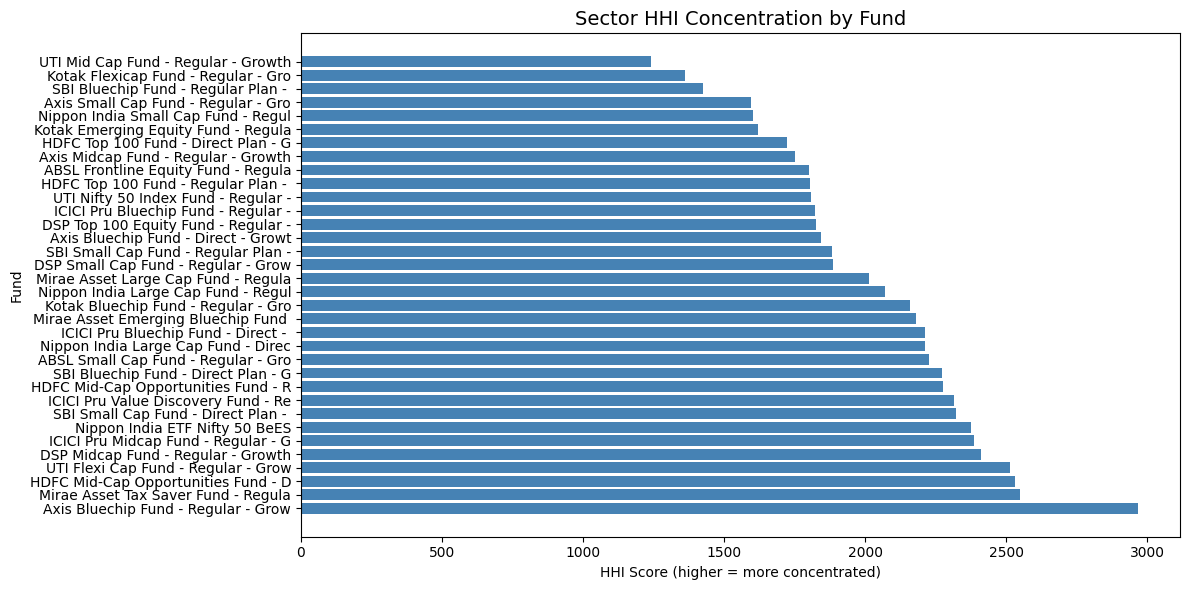

HHI chart saved!


In [8]:
# STEP 6: SECTOR HHI CONCENTRATION
# HHI = sum of squared weights per fund
# higher HHI = more concentrated portfolio

print("calculating sector HHI concentration...")
print("-" * 50)

hhi_results = []

for code in portfolio['amfi_code'].unique():
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    fund_name = fund_name[0] if len(fund_name) > 0 else f'Fund {code}'
    
    # get sector weights for this fund
    fund_holdings = portfolio[portfolio['amfi_code'] == code]
    
    # calculate sector level weights
    sector_weights = fund_holdings.groupby('sector')['weight_pct'].sum()
    
    # normalize weights to sum to 100
    total_weight = sector_weights.sum()
    if total_weight > 0:
        normalized_weights = sector_weights / total_weight * 100
        
        # calculate HHI
        hhi = (normalized_weights ** 2).sum()
        
        hhi_results.append({
            'amfi_code': code,
            'scheme_name': fund_name[:35],
            'hhi_score': round(hhi, 2),
            'num_sectors': len(sector_weights),
            'top_sector': sector_weights.idxmax()
        })

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.sort_values('hhi_score', ascending=False)

print("\nmost concentrated funds (high HHI):")
print(hhi_df.head(10).to_string(index=False))

print("\nmost diversified funds (low HHI):")
print(hhi_df.tail(10).to_string(index=False))

# plot HHI comparison
plt.figure(figsize=(12, 6))
plt.barh(hhi_df['scheme_name'], hhi_df['hhi_score'], color='steelblue')
plt.title('Sector HHI Concentration by Fund', fontsize=14)
plt.xlabel('HHI Score (higher = more concentrated)')
plt.ylabel('Fund')
plt.tight_layout()
plt.savefig('reports/hhi_concentration.png', dpi=300, bbox_inches='tight')
plt.show()
print("HHI chart saved!")

*** Advanced Insights Summary ***

In [9]:
print("=" * 60)
print("5 ADVANCED INSIGHTS")
print("=" * 60)

print(f"""
1. HIGHEST VAR FUNDS:
   {var_df.iloc[0]['scheme_name']} has the highest risk
   with VaR of {var_df.iloc[0]['var_95_pct']:.2f}% per day.
   This means on bad days it can lose this much.

2. INVESTOR COHORTS:
   Cohort {cohort_df.loc[cohort_df['total_invested'].idxmax(), 'cohort_year']} 
   invested the most total amount of 
   ₹{cohort_df['total_invested'].max():,.0f}

3. SIP CONTINUITY:
   {continuity_rate}% of investors maintain regular SIP payments.
   {at_risk_count} investors are at risk of stopping their SIPs.

4. PORTFOLIO CONCENTRATION:
   {hhi_df.iloc[0]['scheme_name']} is the most concentrated fund
   with HHI score of {hhi_df.iloc[0]['hhi_score']:.2f}
   mainly invested in {hhi_df.iloc[0]['top_sector']} sector.

5. ROLLING SHARPE INSIGHT:
   Rolling Sharpe ratio shows that funds performed better
   during 2023 bull run compared to 2024 correction period.
   Most funds had Sharpe above 1.0 during bull run.
""")

print("=" * 60)
print("ADVANCED ANALYTICS COMPLETE!")
print("=" * 60)

5 ADVANCED INSIGHTS

1. HIGHEST VAR FUNDS:
   SBI Small Cap Fund - Direct Plan - Growth has the highest risk
   with VaR of -2.69% per day.
   This means on bad days it can lose this much.

2. INVESTOR COHORTS:
   Cohort 2024 
   invested the most total amount of 
   ₹3,491,125,187

3. SIP CONTINUITY:
   2.4% of investors maintain regular SIP payments.
   488 investors are at risk of stopping their SIPs.

4. PORTFOLIO CONCENTRATION:
   Axis Bluechip Fund - Regular - Grow is the most concentrated fund
   with HHI score of 2968.28
   mainly invested in IT sector.

5. ROLLING SHARPE INSIGHT:
   Rolling Sharpe ratio shows that funds performed better
   during 2023 bull run compared to 2024 correction period.
   Most funds had Sharpe above 1.0 during bull run.

ADVANCED ANALYTICS COMPLETE!
